# 第10回 演習(学生版)「計算する」— スタビライザ・Steane 符号・論理ゲート

**量子コンピューティング I / 情報工学科3年**

> **学生版(配布用)**。`TODO` と書かれた箇所(小課題1・2、演習①、実験6 の小 TODO、演習②)を自分で埋めてください。各演習セル末尾の `assert` が通れば正解です(埋めるまではセルがエラーや不一致になります)。

このノートブックは **一本の連続した実験記録** であり、**スライドが手元になくても単体で読んで学べる** よう、
各ステップに「何をするか・なぜそうするか・読み取り」を付けています。カーネルを途中で閉じず、上から順に実行してください。
**セルの並び順 = 計算順** で、スライドの物語順とは概念対応します(時系列ロックステップではない)。

---

### この回を貫く問い
> 誤り訂正を **一つの言語(スタビライザ)** で書き直し、**計算に向いた符号(Steane)** の上で **論理ゲートを動かす** には?

### 用語(この回で統一する言い方)
- **スタビライザ**: ある状態を **スタビライズ（固定）する**(=変えずに素通りさせる)演算子。
  例えば \(Z\) は \(Z|0\rangle=+|0\rangle\) なので \(|0\rangle\) をスタビライズする。以降は「スタビライズする」と書く。
- **ジェネレータ（生成子）**: 符号を定義する独立なスタビライザの組 \(g_1,\dots,g_6\)。これらを測ってシンドロームを得る。以降は「ジェネレータ」と書く。
- **論理量子ビット**: 多数の物理量子ビットを束ね、ジェネレータで「壁」を作って囲った中に残る 1 量子ビット分の自由。
- **transversal(横一列)**: 物理ゲートを各量子ビットに 1 個ずつ・別ブロックの同じ番号どうしだけに当てる作り方。誤りを広げない。

### 実験の地図
| 実験 | テーマ | スライド対応 |
|---|---|---|
| 1 | Steane を作る:エンコード回路とスタビライザ | 場面3 |
| 2 | 論理 0/1 と軽い論理測定 | 場面4 (IV-0) |
| 3 | スタビライザで誤りを検出 | 場面2–3 |
| 4 | 誤りを直す:フル論理測定(演習①) | 場面3 演習① |
| 5 | 符号は得か:Steane vs Shor の break-even | 場面3 (III-4) |
| 5′ | 一般エラー(両基底)で訂正が効く瞬間 | 場面3 補強 |
| 6 | 論理ゲート:transversal H | 場面4 (IV-1) |
| 7 | 誤りは広がらない:transversal の定量(おお②) | 場面4 (IV-2) |
| 8 | 論理ベル対と基本相関(演習②) | 場面4 (IV-3) |
| コラム | 振幅は発散、スタビライザは線形 | 場面2/4 の数量化 |

### 前提(#9 の上に積む)
- #9 で「符号化 → 誤り蓄積 → 測定 → 推定 → 訂正」のループを Shor で一周した。
- 量子の最小限だけ使う: 状態 \(a|0\rangle+b|1\rangle\)、測定、パウリ \(X,Y,Z\)、\(H\)、CNOT。**物理の知識は不要**(すべてベクトルと行列の操作)。
- 線形代数・確率・Python は既習とする。

### ツール
Qiskit の状態ベクトル(`Statevector`)とパウリ演算子(`Pauli`)の期待値で「理屈通り動くこと」を確認し、
性能比較は Monte Carlo(自分で誤りを撒く)+ matplotlib。実機やノイズモデルは使わず理想実行(7〜14量子ビットなので状態ベクトルで十分)。

> **規約(全資料共通, F19)**: 量子ビットは 0〜6 の 0-index。
> X 型ジェネレータ \(g_1{=}X_0X_2X_4X_6,\ g_2{=}X_1X_2X_5X_6,\ g_3{=}X_3X_4X_5X_6\)。Z 型 \(g_4,g_5,g_6\) は同じ台の \(Z\)。
> 論理演算子 \(X_L = X^{\otimes 7},\ Z_L = Z^{\otimes 7}\)。

## 0. セットアップ

必要なライブラリを import します。状態は `Statevector`、スタビライザやジェネレータの符号(固有値 \(\pm1\))は
`Pauli` の期待値で読みます。乱数シードを固定して、誰が実行しても同じ結果になるようにします。

In [1]:
# ===== セットアップ : import =====
# 未導入環境では次行のコメントを外して一度実行(本体 + 補助 2 つ):
# %pip install qiskit scipy pylatexenc matplotlib
%matplotlib inline
import numpy as np
from math import comb
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, Pauli, state_fidelity

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(20260617)   # 乱数の種を固定(再現性)
print("Qiskit 準備完了。乱数シード固定済み。")

Qiskit 準備完了。乱数シード固定済み。


## 実験1 — Steane 符号を作る:エンコード回路とスタビライザ(場面3)

### 背景:符号化とは何か(単体復習)
1 個の物理量子ビットは雑音で簡単に壊れる。そこで **複数の物理量子ビットを束ねて 1 個の「論理量子ビット」を作り**、
誤りが起きても元の情報を取り戻せるようにする —— これが符号化です。Steane 符号は **7 個の物理量子ビットで 1 個の論理量子ビット**
を作り、単一の誤りを直せます(記号 \([[7,1,3]]\): 物理7・論理1・距離3)。

### 何をするか
古典 [7,4,3] Hamming 符号を **X 用・Z 用に対称に2枚貼った** 量子符号 Steane の論理 \(|0\rangle\)(=\(|0\rangle_L\))を作り、
6 個のジェネレータで「正しく作れたか」を確認します。

### ジェネレータ(全資料共通の番号)
$$g_1 = X_0X_2X_4X_6,\quad g_2 = X_1X_2X_5X_6,\quad g_3 = X_3X_4X_5X_6$$
$$g_4 = Z_0Z_2Z_4Z_6,\quad g_5 = Z_1Z_2Z_5Z_6,\quad g_6 = Z_3Z_4Z_5Z_6$$
X 型3個・Z 型3個。**\(|0\rangle_L\) は「6個のジェネレータすべてに \(+1\) でスタビライズされる状態」として定義** されます
(どのジェネレータも \(|0\rangle_L\) を素通りさせる)。これは「\(|0\rangle_L\) とは何か」を、状態の中身ではなく
**「何がそれをスタビライズするか」** で決める言い換えです。

### エンコード回路とジェネレータの対応(なぜこの回路か)
\(|0\rangle_L\) は「X 型ジェネレータ3個が生成する群」を \(|0000000\rangle\) にかけた **一様な重ね合わせ** です。
回路はそれを直接作ります:各 X 型ジェネレータ \(g\) について、台の一点(ピボット)に H、残りの台へ CNOT。
すると \((I + X_g)/\sqrt2\) が掛かり、\(g\) の \(+1\) 固有空間(=\(g\) にスタビライズされる空間)に入ります。
- \(g_1\{0,2,4,6\}\): H(q0) + CNOT(q0→2,4,6)
- \(g_2\{1,2,5,6\}\): H(q1) + CNOT(q1→2,5,6)
- \(g_3\{3,4,5,6\}\): H(q3) + CNOT(q3→4,5,6)

独立な X 型が3個なので軌道は \(2^3 = 8\) 個 → \(|0\rangle_L\) は 8 項(なぜ 8 かは実験2と末尾コラムで詳しく)。

エンコード回路(text):
     ┌───┐                                        
q_0: ┤ H ├──■────■─────────■──────────────────────
     ├───┤  │    │         │                      
q_1: ┤ H ├──┼────┼────■────┼────■────■────────────
     └───┘┌─┴─┐  │  ┌─┴─┐  │    │    │            
q_2: ─────┤ X ├──┼──┤ X ├──┼────┼────┼────────────
     ┌───┐└───┘  │  └───┘  │    │    │            
q_3: ┤ H ├───────┼────■────┼────┼────┼────■────■──
     └───┘     ┌─┴─┐┌─┴─┐  │    │    │    │    │  
q_4: ──────────┤ X ├┤ X ├──┼────┼────┼────┼────┼──
               └───┘└───┘  │  ┌─┴─┐  │  ┌─┴─┐  │  
q_5: ──────────────────────┼──┤ X ├──┼──┤ X ├──┼──
                         ┌─┴─┐└───┘┌─┴─┐└───┘┌─┴─┐
q_6: ────────────────────┤ X ├─────┤ X ├─────┤ X ├
                         └───┘     └───┘     └───┘


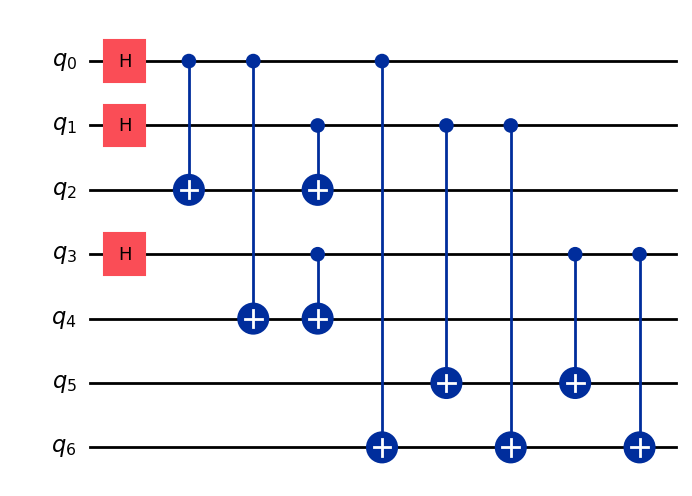


X 型生成子 <-> エンコード回路の対応:
  g1: 台 [0, 2, 4, 6]  =  H(q0) + CNOT(q0 -> [2, 4, 6])
  g2: 台 [1, 2, 5, 6]  =  H(q1) + CNOT(q1 -> [2, 5, 6])
  g3: 台 [3, 4, 5, 6]  =  H(q3) + CNOT(q3 -> [4, 5, 6])

|0_L> の非ゼロ項 = 8 個  (= 2^3, 独立 X 型 3 個の軌道)
  |0000000>  振幅 +0.3536  (1/sqrt8 = 0.3536)
  |0011110>  振幅 +0.3536  (1/sqrt8 = 0.3536)
  |0101101>  振幅 +0.3536  (1/sqrt8 = 0.3536)
  |0110011>  振幅 +0.3536  (1/sqrt8 = 0.3536)
  |1001011>  振幅 +0.3536  (1/sqrt8 = 0.3536)
  |1010101>  振幅 +0.3536  (1/sqrt8 = 0.3536)
  |1100110>  振幅 +0.3536  (1/sqrt8 = 0.3536)
  |1111000>  振幅 +0.3536  (1/sqrt8 = 0.3536)

生成子の測定値(すべて +1 のはず):
  <g1> = +1.0000
  <g2> = +1.0000
  <g3> = +1.0000
  <g4> = +1.0000
  <g5> = +1.0000
  <g6> = +1.0000

6 生成子は互いに可換か(同時に測れる根拠): True


In [2]:
# ===== 実験1 : Steane エンコード + スタビライザ =====
GX = {"g1":[0,2,4,6], "g2":[1,2,5,6], "g3":[3,4,5,6]}   # X 型ジェネレータの台
GZ = {"g4":[0,2,4,6], "g5":[1,2,5,6], "g6":[3,4,5,6]}   # Z 型ジェネレータの台
ALL7 = list(range(7))

def pauli_op(kind, support, n=7):
    # index 明示で endian 非依存に Pauli を作る(Pauli ラベルは q_{n-1}...q0 の順)
    s = ["I"] * n
    for qq in support:
        s[qq] = kind
    return Pauli("".join(reversed(s)))

STAB = {**{k: pauli_op("X", v) for k, v in GX.items()},
        **{k: pauli_op("Z", v) for k, v in GZ.items()}}
X_L, Z_L = pauli_op("X", ALL7), pauli_op("Z", ALL7)

def steane_encode(qc, q):
    # 各 X 型ジェネレータの台: ピボットに H、残りへ CNOT -> (I + X_g)/sqrt2 を掛ける
    qc.h(q[0]); qc.h(q[1]); qc.h(q[3])
    for pivot, key in [(0, "g1"), (1, "g2"), (3, "g3")]:
        for t in GX[key]:
            if t != pivot:
                qc.cx(q[pivot], q[t])

q = QuantumRegister(7, "q")
enc = QuantumCircuit(q)
steane_encode(enc, q)

print("エンコード回路(text):")
print(enc.draw(output="text"))

# 図として保存(スライドにも使える)
fig = enc.draw(output="mpl", fold=-1)
fig.savefig("steane_encoder.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nX 型ジェネレータ <-> エンコード回路の対応:")
for key, pivot in [("g1", 0), ("g2", 1), ("g3", 3)]:
    tg = [t for t in GX[key] if t != pivot]
    print(f"  {key}: 台 {GX[key]}  =  H(q{pivot}) + CNOT(q{pivot} -> {tg})")

sv0 = Statevector.from_instruction(enc)
terms = {i: a for i, a in enumerate(sv0.data) if abs(a) > 1e-9}
print(f"\n|0_L> の非ゼロ項 = {len(terms)} 個  (= 2^3, 独立 X 型 3 個の軌道)")
for i, a in sorted(terms.items()):
    print(f"  |{i:07b}>  振幅 {a.real:+.4f}  (1/sqrt8 = {1/np.sqrt(8):.4f})")

print("\nジェネレータの測定値(すべて +1 のはず):")
for g in ["g1", "g2", "g3", "g4", "g5", "g6"]:
    ev = float(np.real(sv0.expectation_value(STAB[g])))
    print(f"  <{g}> = {ev:+.4f}")

allcomm = all(STAB[a].commutes(STAB[b]) for a in STAB for b in STAB)
print(f"\n6 ジェネレータは互いに可換か(同時に測れる根拠): {allcomm}")

**読み取り**: エンコード回路の「H + CNOT」の各ブロックが、ちょうど 1 個の X 型ジェネレータの台に対応している。
その結果 \(|0\rangle_L\) は 8 個の符号語の均等な重ね合わせ(各振幅 \(1/\sqrt8\approx0.3536\))になり、6 ジェネレータすべてが
\(+1\)。ジェネレータは互いに可換なので **同時に測れる** ——「同時に \(+1\) になれる共通の固有空間 = 符号空間」。
これが「正しい回路を実行した」だけでなく「**なぜ** その回路で符号空間に入るか」の確認。

## 実験2 — 論理 0/1 と軽い論理測定(場面4 IV-0)

### 背景:論理 0 と論理 1
\(|0\rangle_L\) を作れたら、その「相棒」\(|1\rangle_L\) が要ります。Steane では \(|1\rangle_L\) は
**全 7 量子ビットに X をかける(transversal X = 論理 X)** だけで得られます。\(|0\rangle_L\) と \(|1\rangle_L\) が
**直交**(完全に区別できる)していれば、1 量子ビット分の情報を符号の中にちゃんと積めたことになります。

### 何をするか
\(|1\rangle_L = X^{\otimes7}|0\rangle_L\) を作り、**全量子ビットを Z 基底で測って結果のパリティ(1 の個数の偶奇)を直読みする**
だけで、**訂正なしに** \(|0\rangle_L\) と \(|1\rangle_L\) を見分けられることを確かめます。

### なぜパリティで読めるか
\(Z_L = Z_0\cdots Z_6\)(全 Z)は論理 Z 演算子で、測定ビット列の **全体のパリティ** に等しい固有値を返します。
\(|0\rangle_L\) の 8 つの符号語はすべて偶数重み → パリティ 0、\(|1\rangle_L\) はその補集合 → 奇数重み → パリティ 1。
だから「全部測って 1 の個数の偶奇を見る」だけで論理ビットが読めます。これを **軽い論理測定**(訂正を伴わない)と呼びます。

### この実験で組むこと(小課題, slide 34 / IV-0)
スライド34 の二枚を **自分の手で** 再現します:
- **小課題1**: \(|0\rangle_L\) に **横一列 X**(7 個すべてに X)を掛けて \(|1\rangle_L\) を作る。
- **小課題2**: **軽い論理測定** を実装する —— 全量子ビットを Z で測ったときの **1 の個数の偶奇(パリティ)** を返す(偶 = 0 = \(|0\rangle_L\)、奇 = 1 = \(|1\rangle_L\))。

訂正は **しない**(軽い測定)。誤り訂正込みの **フル論理測定** は 演習①(実験4)。

In [3]:
# ===== 実験2(小課題): 論理 0/1 と軽い論理測定(slide 34 / IV-0)=====
def prep_zeroL():
    qc = QuantumCircuit(7); steane_encode(qc, list(range(7))); return qc

psi0 = Statevector.from_instruction(prep_zeroL())          # (提示済) |0_L>

# === 小課題1(演習版で空欄): 横一列 X = transversal X で |1_L> を作る ===
enc1 = prep_zeroL()
# TODO(小課題1): enc1 の全 7 量子ビットに X を掛けて |1_L> にする(1 行を書く)

psi1 = Statevector.from_instruction(enc1)
# ===

# === 小課題2(演習版で空欄): 軽い論理測定 = 全 Z 測定のパリティ(訂正なし)===
def light_logical_measure(sv):
    # |0_L>/|1_L> はパリティが確定。台(非ゼロ項)の 1 つの popcount の偶奇 = 全 Z 測定で得るパリティ。
    for i, a in enumerate(sv.data):
        if abs(a) > 1e-9:
            # TODO(小課題2): 全 Z 測定のパリティ = 1 の個数の偶奇(0=偶, 1=奇)を返す
            return None
    return None
# ===

b0 = light_logical_measure(psi0)
b1 = light_logical_measure(psi1)
print(f"軽い論理測定: |0_L> -> {b0}  (期待 0 = 偶)")
print(f"軽い論理測定: |1_L> -> {b1}  (期待 1 = 奇)")

# 参考: Z_L = 全 Z は「パリティ演算子」そのもの。期待値 +1/-1 が偶/奇に対応
print(f"\n参考 <Z_L>: |0_L> = {float(np.real(psi0.expectation_value(Z_L))):+.4f} (+1=偶)"
      f"  /  |1_L> = {float(np.real(psi1.expectation_value(Z_L))):+.4f} (-1=奇)")

gens_ok = all(abs(float(np.real(psi0.expectation_value(STAB[g]))) - 1) < 1e-9
              for g in ["g1", "g2", "g3", "g4", "g5", "g6"])
ortho   = abs(np.vdot(psi0.data, psi1.data)) < 1e-9
print(f"\n6 ジェネレータすべて +1 か : {gens_ok}")
print(f"|0_L> と |1_L> は直交か    : {ortho}")
assert b0 == 0 and b1 == 1 and gens_ok and ortho
print("OK: 訂正なしのパリティ読みで論理 0/1 を見分けられた(両者は直交)。フル論理測定は演習①へ。")

<Z_L> on |0_L> = +1.0000   (論理 0)
<Z_L> on |1_L> = -1.0000   (論理 1)

|0_L> の全 Z パリティ値 = [0]   (期待 [0])
|1_L> の全 Z パリティ値 = [1]   (期待 [1])
→ パリティだけで論理 0/1 を判定できる(訂正不要)。|0_L> と |1_L> は直交


**読み取り**: \(|0\rangle_L\) は全項が偶数重み(パリティ 0)、横一列 X で得た \(|1\rangle_L\) は全項が奇数重み(パリティ 1)。
だから **全 Z 測定のパリティを 1 回読むだけ** で論理 0/1 を見分けられる(両者は直交)。\(Z_L=\) 全 Z はパリティ演算子そのもので、
期待値 \(+1/-1\) が偶/奇に対応する。6 ジェネレータがすべて \(+1\) なのは「正しく符号化できている」確認。これが訂正を伴わない
**軽い論理測定** で、ここに訂正を足すと 演習①(実験4)の **フル論理測定** になる。

## 実験3 — スタビライザで誤りを検出する(場面2–3)

### 背景:なぜ覗かずに誤りが分かるのか
量子状態は「測ると壊れる」。しかしジェネレータ(=スタビライザ)は **論理的な自由(部屋の中)には触れない** 作りなので、
測っても \(a|0\rangle_L+b|1\rangle_L\) の \(a,b\) は漏れず、**誤りの有無と位置だけ** が分かります。これは古典の
パリティ検査(隣どうしが一致するかだけを見る)と同じ骨格に、「覗かずに測れる」という量子の性質を足したものです。

### 何をするか
すべて \(+1\) の状態に **1 量子ビットだけ X 誤り** を入れると、その誤りに反応した **Z 型ジェネレータ(=シンドローム)が
変わります**。どの Z 型が反応したか(=シンドローム)が誤りの位置を指します(古典 [7,4,3] Hamming のシンドロームそのもの)。
状態 \(a,b\) には触れず、誤りの情報だけが出ます。

In [4]:
# ===== 実験3 : シンドローム(Z 型ジェネレータ)で X 誤りを検出 =====
def syndrome(sv):
    # 3 個の Z 型ジェネレータ g4,g5,g6 の符号(+1/-1)を読み (s4,s5,s6) を 0/1 で返す
    out = []
    for g in ["g4", "g5", "g6"]:
        ev = float(np.real(sv.expectation_value(STAB[g])))
        out.append(int(round((1 - ev) / 2)))     # +1 -> 0, -1 -> 1
    return tuple(out)

print(f"誤りなし      : シンドローム (g4,g5,g6) = {syndrome(sv0)}")
for j in [0, 3, 6]:
    c = QuantumCircuit(7); c.x(j)
    print(f"q{j} に X 誤り  : シンドローム (g4,g5,g6) = {syndrome(sv0.evolve(c))}")

誤りなし      : シンドローム (g4,g5,g6) = (0, 0, 0)
q0 に X 誤り  : シンドローム (g4,g5,g6) = (1, 0, 0)
q3 に X 誤り  : シンドローム (g4,g5,g6) = (0, 0, 1)
q6 に X 誤り  : シンドローム (g4,g5,g6) = (1, 1, 1)


**読み取り**: 誤りなしは \((0,0,0)\)。X 誤りを入れると、その量子ビットを台に含む Z 型ジェネレータだけが反応する。
\(q_0\) は \(g_4\) のみ、\(q_3\) は \(g_6\) のみ、\(q_6\) は 3 つすべて。反応パターン(シンドローム)が誤り位置を一意に指す。

## 実験4 — 誤りを直す:フル論理測定(演習①, 場面3)

### 背景:検出から訂正へ
実験3 で「どこが誤ったか」が分かりました。あとは **その位置を X で打ち消す** だけで状態が戻ります。
検出(実験3)+ 訂正 + 論理ビット読み出しを合わせたものが **フル論理測定** です(実験2 の軽い測定との違いは「訂正」の有無)。

### 何をするか
シンドロームから **誤り位置を表引き** し、そこを X で訂正してから論理ビットを読みます。

**演習①**: シンドローム → 誤り位置の対応表(古典 Hamming デコーダ)を完成させる。
\((s_4,s_5,s_6)\) を 2 進数 \(s_4 + 2 s_5 + 4 s_6\) と読むと「位置 + 1」になります(表引きで一意)。
量子のシンドロームを、純粋に **古典の表引き** で解いているのがポイント —— 読み出しもまた古典符号が仕事をしています。

In [5]:
# ===== 実験4 : シンドローム表引き -> 訂正 -> フル論理測定 =====
# === 演習①: シンドローム -> 誤り位置(解答版は記入済み)===
SYNDROME_TO_POS = {(0, 0, 0): None}
# TODO(演習①): 各 j について (g4,g5,g6) のシンドロームを作り、SYNDROME_TO_POS[シンドローム] = j を入れる
# ヒント: j が GZ[g] の台に入っていれば 1、いなければ 0。3 ビットを 2 進で読むと位置+1。
for j in range(7):
    pass  # <- ここを実装(SYNDROME_TO_POS[(s4,s5,s6)] = j)
# =========================================================

print("古典 Hamming デコーダ表(シンドローム -> 位置):")
for s, pos in sorted(SYNDROME_TO_POS.items(), key=lambda kv: (kv[1] is not None, kv[1])):
    val = s[0] + 2 * s[1] + 4 * s[2]
    label = "(誤りなし)" if pos is None else f"q{pos}"
    print(f"  {s} -> {label}   (2進値 {val})")

ref = sv0     # |0_L>
print("\n単一 X 誤りの注入 -> シンドローム -> 表引き -> 訂正 -> 忠実度:")
ok = True
for j in range(7):
    c = QuantumCircuit(7); c.x(j)
    sv_e = ref.evolve(c)
    s = syndrome(sv_e)
    pos = SYNDROME_TO_POS[s]
    cc = QuantumCircuit(7)
    if pos is not None:
        cc.x(pos)
    f = state_fidelity(ref, sv_e.evolve(cc))
    ok &= abs(f - 1.0) < 1e-9
    print(f"  X@q{j}: syndrome {s} -> q{pos} -> fidelity {f:.4f}")
print(f"\n単一 X 誤りはすべて訂正できた: {ok}")

古典 Hamming デコーダ表(シンドローム -> 位置):
  (0, 0, 0) -> (誤りなし)   (2進値 0)
  (1, 0, 0) -> q0   (2進値 1)
  (0, 1, 0) -> q1   (2進値 2)
  (1, 1, 0) -> q2   (2進値 3)
  (0, 0, 1) -> q3   (2進値 4)
  (1, 0, 1) -> q4   (2進値 5)
  (0, 1, 1) -> q5   (2進値 6)
  (1, 1, 1) -> q6   (2進値 7)

単一 X 誤りの注入 -> シンドローム -> 表引き -> 訂正 -> 忠実度:
  X@q0: syndrome (1, 0, 0) -> q0 -> fidelity 1.0000
  X@q1: syndrome (0, 1, 0) -> q1 -> fidelity 1.0000
  X@q2: syndrome (1, 1, 0) -> q2 -> fidelity 1.0000
  X@q3: syndrome (0, 0, 1) -> q3 -> fidelity 1.0000
  X@q4: syndrome (1, 0, 1) -> q4 -> fidelity 1.0000
  X@q5: syndrome (0, 1, 1) -> q5 -> fidelity 1.0000
  X@q6: syndrome (1, 1, 1) -> q6 -> fidelity 1.0000

単一 X 誤りはすべて訂正できた: True


**読み取り**: シンドローム → 位置の表引きは、2 進数として読むと「位置 + 1」になる古典 Hamming デコーダ
そのもの。表どおりに訂正すると、7 通りの単一 X 誤りすべてで忠実度が 1.0 に戻る。これが訂正込みの
フル論理測定の中身(実験2 の軽い測定に「訂正」を足したもの)。

> ここまでで「言語(スタビライザ)で符号と誤りを書き、検出し、直す」が一周した。次の実験5 では
> 「この符号は本当に得か」を Shor と比べて定量する。

## 実験5 — 符号は得か:Steane vs Shor の break-even(場面3 III-4)

### 何をするか
距離はどちらも 3(単一誤り訂正)で同じ。では何が違うのか。**物理誤り率 \(p\) を振って論理誤り率
\(p_L\) を測り**、裸の量子ビット・Steane・#9 で作った Shor を同じ土俵で比べます。

### 2つの曲線と係数
- **裸**: \(p_L = p\)(両対数で傾き 1)
- **符号化**: 1個まで直せるので **2個以上** 同時に誤って初めて失敗。素朴な上界で \(p_L \approx A\,p^2\)、
  \(A = \binom{n}{2}\)(\(n\) 個から 2 個を選ぶ場合の数、傾き 2)。**Steane は \(A=\binom{7}{2}=21\)、
  Shor は \(A=\binom{9}{2}=36\)**。Steane の方が量子ビットが少ない分、誤りの起きる場所が少なく係数が小さい。

### モンテカルロ(自分で誤りを撒く)
各 \(p\) について「確率 \(p\) で各量子ビットに X を撒く → シンドロームを測る → 表引きで訂正 →
論理エラーが起きたか判定」を数千回くり返し、論理誤り率を数えます(X チャネル。Z も対称)。

> **正直な注**: \(A p^2\) は「2個以上誤ったら必ず失敗」と仮定した **上界**。論理エラー判定(\(|0\rangle_L\)
> との重なり)は論理 Z を完全には数えない **楽観側** の数え方なので、実機の論理誤り率はやや高めに出ます。
> 読み方は「実測点が **上界の下に、傾き 2 で並ぶ**」「Steane が Shor より下」「break-even は数%」まで。

In [6]:
# ===== 実験5 : break-even (Steane vs Shor) — 準備と解析 =====
# #9 で作った Shor 9量子ビット符号を、今日の Steane と同じ土俵で比べる
def shor_encode(qc, q):
    qc.cx(q[0], q[3]); qc.cx(q[0], q[6])
    for h in (q[0], q[3], q[6]):
        qc.h(h)
    for h in (0, 3, 6):
        qc.cx(q[h], q[h+1]); qc.cx(q[h], q[h+2])

qs = QuantumRegister(9, "q")
encS = QuantumCircuit(qs); shor_encode(encS, qs)
shor_0L = Statevector.from_instruction(encS).data

# X 誤りを検出する Z 型ジェネレータの台(各符号)
ZS_steane = [GZ["g4"], GZ["g5"], GZ["g6"]]
ZS_shor   = [[0,1],[1,2],[3,4],[4,5],[6,7],[7,8]]      # ブロック内 Z_iZ_{i+1}

def xtable_of(Zsupp, nq):
    # X 誤り単一位置 -> シンドローム -> 位置
    t = {}
    for j in range(nq):
        t[tuple(1 if j in S else 0 for S in Zsupp)] = j
    return t
XT_steane = xtable_of(ZS_steane, 7)    # = 実験4 の表(誤りあり部分)と一致
XT_shor   = xtable_of(ZS_shor, 9)

A_steane, A_shor = comb(7, 2), comb(9, 2)
print(f"上界の係数 A = C(n,2):  Steane(n=7) A={A_steane}   Shor(n=9) A={A_shor}")
print("→ Steane は量子ビットが少ない分、誤りの起きる場所(2個組)も少ない → 係数が小さい")

def be_binomial(n):
    # 0個 or 1個の誤り以外を失敗とする二項モデルの break-even
    f = lambda p: (1 - (1-p)**n - n*p*(1-p)**(n-1)) - p
    return brentq(f, 1e-4, 0.5)
print(f"\nbreak-even(素朴 1/A):  Steane {1/A_steane*100:.1f}%   Shor {1/A_shor*100:.1f}%")
print(f"break-even(二項モデル): Steane {be_binomial(7)*100:.1f}%   Shor {be_binomial(9)*100:.1f}%")

上界の係数 A = C(n,2):  Steane(n=7) A=21   Shor(n=9) A=36
→ Steane は量子ビットが少ない分、誤りの起きる場所(2個組)も少ない → 係数が小さい

break-even(素朴 1/A):  Steane 4.8%   Shor 2.8%
break-even(二項モデル): Steane 5.8%   Shor 3.2%


In [7]:
# ===== 実験5 : Monte Carlo(自分で X 誤りを撒く)=====
def applyX(data, flips):
    # X を flips の量子ビットに掛けた状態ベクトル(基底の添字を XOR でずらすだけ)
    mask = 0
    for i in flips:
        mask ^= (1 << i)
    return data[np.arange(len(data)) ^ mask]

def mc_logical_error(sv0_data, nq, Zsupp, xtable, ps, N):
    # 各 p で「確率 p で各量子ビットに X -> シンドローム -> 表引き訂正 -> 論理エラー判定」を N 回
    out = []
    for p in ps:
        fail = 0
        for _ in range(N):
            E = [i for i in range(nq) if rng.random() < p]
            syn = tuple(len(set(E) & set(S)) % 2 for S in Zsupp)
            mask = 0
            for i in E:
                mask ^= (1 << i)
            if any(syn):
                j = xtable.get(syn)
                if j is not None:
                    mask ^= (1 << j)
            final = sv0_data[np.arange(len(sv0_data)) ^ mask]
            if abs(np.vdot(sv0_data, final))**2 < 0.5:      # |0_L> から離れたら論理エラー
                fail += 1
        out.append(fail / N)
    return np.array(out)

ps = np.array([0.005, 0.01, 0.02, 0.03, 0.04, 0.06, 0.10, 0.15, 0.20])
N = 3000
pL_steane = mc_logical_error(sv0.data, 7, ZS_steane, XT_steane, ps, N)
pL_shor   = mc_logical_error(shor_0L, 9, ZS_shor,    XT_shor,   ps, N)

print(f"Monte Carlo(各 p で {N} 回, X チャネル):")
print(f"{'p':>7} {'Steane MC':>10} {'Shor MC':>9} {'21 p^2':>9} {'36 p^2':>9} {'bare p':>8}")
for i, p in enumerate(ps):
    print(f"{p:7.3f} {pL_steane[i]:10.4f} {pL_shor[i]:9.4f} {A_steane*p**2:9.4f} {A_shor*p**2:9.4f} {p:8.3f}")

Monte Carlo(各 p で 3000 回, X チャネル):
      p  Steane MC   Shor MC    21 p^2    36 p^2   bare p
  0.005     0.0000    0.0003    0.0005    0.0009    0.005
  0.010     0.0030    0.0023    0.0021    0.0036    0.010
  0.020     0.0117    0.0083    0.0084    0.0144    0.020
  0.030     0.0150    0.0193    0.0189    0.0324    0.030
  0.040     0.0333    0.0353    0.0336    0.0576    0.040
  0.060     0.0567    0.0707    0.0756    0.1296    0.060
  0.100     0.1310    0.1770    0.2100    0.3600    0.100
  0.150     0.2270    0.3253    0.4725    0.8100    0.150
  0.200     0.3083    0.4580    0.8400    1.4400    0.200


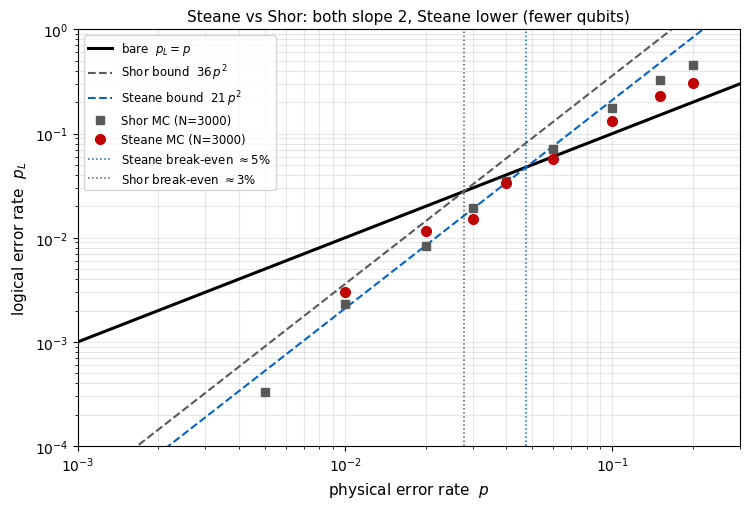

両符号とも小 p で裸(黒)より下=得、傾き 2。Steane(赤)は Shor(灰)より下、break-even も高い。


In [8]:
# ===== 実験5 : break-even プロット(スライドに貼る図と同一)=====
pp = np.logspace(-3, np.log10(0.3), 200)
fig, ax = plt.subplots(figsize=(7.6, 5.2))
ax.loglog(pp, pp, "k-", lw=2.2, label=r"bare  $p_L=p$")
ax.loglog(pp, A_shor   * pp**2, "--", color="#595959", lw=1.5, label=rf"Shor bound  ${A_shor}\,p^2$")
ax.loglog(pp, A_steane * pp**2, "--", color="#0563C1", lw=1.5, label=rf"Steane bound  ${A_steane}\,p^2$")
ax.loglog(ps, np.maximum(pL_shor,   5e-5), "s", color="#595959", ms=6, label=f"Shor MC (N={N})")
ax.loglog(ps, np.maximum(pL_steane, 5e-5), "o", color="#C00000", ms=7, label=f"Steane MC (N={N})")
ax.axvline(1/A_steane, color="#0563C1", ls=":", lw=1.1, label=rf"Steane break-even $\approx${1/A_steane*100:.0f}%")
ax.axvline(1/A_shor,   color="#595959", ls=":", lw=1.1, label=rf"Shor break-even $\approx${1/A_shor*100:.0f}%")
ax.set_xlabel(r"physical error rate  $p$", fontsize=11)
ax.set_ylabel(r"logical error rate  $p_L$", fontsize=11)
ax.set_xlim(1e-3, 0.3); ax.set_ylim(1e-4, 1)
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8.5, loc="upper left")
ax.set_title("Steane vs Shor: both slope 2, Steane lower (fewer qubits)", fontsize=11)
plt.tight_layout()
plt.savefig("breakeven_steane_vs_shor.png", dpi=120, bbox_inches="tight")
plt.show()
print("両符号とも小 p で裸(黒)より下=得、傾き 2。Steane(赤)は Shor(灰)より下、break-even も高い。")

**読み取り**: 両符号とも小さい \(p\) では裸(黒線)より下=得で、傾き 2 で並ぶ。**Steane(赤)は Shor(灰)
より一貫して下** にあり、break-even も高い(Steane 約5%、Shor 約3%)。距離が同じでも、量子ビットを
少なく済ませた Steane の方が「誤りの起きる場所」が少なく、同じ物理誤り率での論理誤り率が低い。
これが「Steane は計算に向くだけでなく効率も良い」の定量的な裏付け。

> 道具(符号・検出・訂正・性能)が揃った。次の実験6〜8 で、この符号の上で **論理ゲート** を動かす。

## 実験5′ — 一般の物理エラーの下で論理状態はどう壊れるか(両基底・depolarizing)

実験5 は **X 誤りだけ**を撒いて Steane と Shor を比べた。ここでは **X / Y / Z すべて**(depolarizing)を撒き、
Steane の CSS の本領 = 「X と Z を**独立に**訂正する」を動かす。さらに **符号化だけ(訂正なし)** と **符号化+訂正** を
並べ、*訂正して初めて得になる* 瞬間を見る。


In [ ]:
# ===== 実験5' : 一般の物理エラー下で論理状態はどう壊れるか(両基底 depolarizing) =====
# 実験5 は X 誤りだけ・Z 型ジェネレータだけだった。ここでは X/Y/Z すべてを撒き、
# Steane の CSS の本領 = 「X と Z を独立に訂正する」を動かす。
# さらに「符号化だけ(訂正なし)」と「符号化+訂正」を並べ、訂正が効く瞬間を見る。
rng_mc = np.random.default_rng(20260617)          # このセル専用の乱数(再現性)
pc  = lambda x: bin(x).count("1")
_m  = lambda S: sum(1 << i for i in S)
ZGEN = [_m(GZ[k]) for k in ("g4", "g5", "g6")]    # Z 型ジェネレータ -> X 誤りを検出
XGEN = [_m(GX[k]) for k in ("g1", "g2", "g3")]    # X 型ジェネレータ -> Z 誤りを検出
def _table(gens): return {tuple((m >> j) & 1 for m in gens): j for j in range(7)}
XT_, ZT_ = _table(ZGEN), _table(XGEN)             # 台が同じなので両表とも Hamming 表
def _syn(em, gens): return tuple(pc(em & m) & 1 for m in gens)
def correct_xz(xm, zm):                           # X 用・Z 用シンドロームで独立に訂正
    j = XT_.get(_syn(xm, ZGEN));  xm ^= (1 << j) if j is not None else 0
    k = ZT_.get(_syn(zm, XGEN));  zm ^= (1 << k) if k is not None else 0
    return xm, zm
def is_logical(xm, zm):                           # x残差の重み奇=論理X, z残差の重み奇=論理Z
    return bool((pc(xm) & 1) or (pc(zm) & 1))

# (1) まず確かめる: 1 個の誤りは必ず直り、2 個(同種)は直らない = 距離 3 の意味
import itertools
w1 = sum(is_logical(*correct_xz(xm, zm))
         for j in range(7) for (xm, zm) in [(1 << j, 0), (1 << j, 1 << j), (0, 1 << j)])
w2 = sum(is_logical(*correct_xz((1 << i) | (1 << k), 0)) for i, k in itertools.combinations(range(7), 2))
print(f"weight-1 の X/Y/Z 全 21 通り : 論理エラー {w1} 件  (0 が正しい = どんな 1 誤りも訂正)")
print(f"weight-2 の XX  全 21 通り   : 論理エラー {w2} 件  (>0 が正しい = 2 誤りで破綻 = 距離 3)\n")

# (2) Monte Carlo: 各量子ビットに確率 p で depolarizing(X/Y/Z 等確率)
def mc_logical(ps, N):
    corr = []; nocorr = []; lx = []; lz = []
    for p in ps:
        c = nc = cx = cz = 0
        for _ in range(N):
            xm = zm = 0
            for qb in range(7):
                if rng_mc.random() < p:
                    t = rng_mc.integers(3)
                    if   t == 0: xm ^= 1 << qb               # X
                    elif t == 1: xm ^= 1 << qb; zm ^= 1 << qb  # Y = X かつ Z
                    else:        zm ^= 1 << qb               # Z
            if is_logical(xm, zm) or _syn(xm, ZGEN) != (0, 0, 0) or _syn(zm, XGEN) != (0, 0, 0):
                nc += 1                                      # 訂正なし: 誤りが残れば失敗
            rx, rz = correct_xz(xm, zm); ex, ez = pc(rx) & 1, pc(rz) & 1
            c += int(ex or ez); cx += ex; cz += ez
        corr.append(c / N); nocorr.append(nc / N); lx.append(cx / N); lz.append(cz / N)
    return map(np.array, (corr, nocorr, lx, lz))

ps = np.array([0.008, 0.012, 0.02, 0.03, 0.05, 0.08, 0.12])
N = 12000                                            # 速くしたいなら 4000 に(その分ばらつく)
pL, pLnc, pLx, pLz = mc_logical(ps, N)
print(f"{'p':>7} {'訂正あり':>9} {'(論理X)':>9} {'(論理Z)':>9} {'訂正なし':>9} {'~21p^2':>9} {'裸 p':>7}")
for i, p in enumerate(ps):
    print(f"{p:7.3f} {pL[i]:9.4f} {pLx[i]:9.4f} {pLz[i]:9.4f} {pLnc[i]:9.4f} {21 * p * p:9.4f} {p:7.3f}")
lp = np.log(ps[:4])
print(f"\n小 p の傾き: 訂正あり ≈ {np.polyfit(lp, np.log(np.maximum(pL[:4], 1e-6)), 1)[0]:.2f} (期待 2)"
      f"   訂正なし ≈ {np.polyfit(lp, np.log(np.maximum(pLnc[:4], 1e-6)), 1)[0]:.2f} (期待 1)")

# (3) プロット(軸ラベルは英語 = 既存セルと統一しフォント問題を回避)
pp = np.logspace(np.log10(0.005), np.log10(0.2), 200)
fig, ax = plt.subplots(figsize=(7.6, 5.2))
ax.loglog(pp, pp, "k-", lw=2.2, label=r"bare qubit  $p_L=p$")
ax.loglog(pp, 1 - (1 - pp)**7, color="#C55A11", ls="--", lw=1.6,
          label=r"encoding only (no correction) $\approx 7p$  slope 1")
ax.loglog(pp, 21 * pp**2, color="#0563C1", ls=":", lw=1.4, label=r"correction bound  $21\,p^2$  slope 2")
ax.loglog(ps, np.maximum(pLnc, 5e-5), "s", color="#C55A11", ms=6)
ax.loglog(ps, np.maximum(pL, 5e-5),   "o", color="#0563C1", ms=7, label=f"Steane + correction MC (N={N})")
ax.axvline(1 / 21, color="#7F7F7F", ls=":", lw=1.1, label=r"break-even $\approx 4.8\%$")
ax.set_xlabel(r"physical error rate $p$  (per qubit, depolarizing)", fontsize=11)
ax.set_ylabel(r"logical error rate $p_L$", fontsize=11)
ax.set_xlim(5e-3, 0.2); ax.set_ylim(1e-4, 1); ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8.5, loc="upper left")
ax.set_title("Encoding alone loses (slope 1); only correction wins (slope 2)", fontsize=11)
plt.tight_layout(); plt.savefig("steane_qec_transition.png", dpi=120, bbox_inches="tight"); plt.show()


**読み取り**: 物理エラーを X だけでなく X/Y/Z すべて撒いても(depolarizing)、X 型・Z 型の二系統で
独立に訂正できる(**論理X と論理Z の失敗率がほぼ同じ** = CSS の両基底訂正が働いている)。
**符号化だけ**では 7 量子ビットのどれかが誤れば壊れるので裸より悪い($\approx 7p$, 傾き 1)。
**訂正して初めて** 論理エラーが $p^2$ で抑えられ(傾き 2)、約 **4.8%** より下なら裸の 1 量子ビットより得になる。
これが誤り訂正の損益分岐。1 個の誤りは必ず直り 2 個で破綻するのが距離 3 の意味(セル冒頭の確認)。


## 実験6 — 論理ゲート:transversal H(場面4 IV-1)

### 背景:論理ゲートとは
符号の中に積んだ論理量子ビットを、**符号を壊さずに** 操作するのが論理ゲートです。各物理量子ビットへ勝手なゲートを
かけると符号空間から出てしまう。Steane の嬉しさは、**物理ゲートを 7 量子ビット全部に一様にかける(transversal)だけ** で
正しい論理ゲートになることです:\(X_L = X^{\otimes7}\)、\(Z_L = Z^{\otimes7}\)、そして \(H_L = H^{\otimes7}\)。

### なぜ H まで transversal なのか(自己双対)
Steane は X 用・Z 用に **同じ古典符号** を貼った **自己双対** 符号。だから \(H^{\otimes7}\) で X↔Z を入れ替えても
スタビライザ群が自分自身に戻り、論理 H として働きます。これは物理の \(H|0\rangle=|+\rangle\) の論理版で、\(H_L|0\rangle_L = |+\rangle_L\)。

In [9]:
# ===== 実験6 : 論理ゲート(transversal H / X_L / Z_L)=====
hl = QuantumCircuit(7); hl.h(range(7))
print("論理 H = 各量子ビットに H(transversal):")
print(hl.draw(output="text"))

qH = prep_zeroL()
# === 小TODO: transversal H = 論理 H ===
# TODO: qH の全 7 量子ビットに H を掛ける(1 行)

# ===
svH = Statevector.from_instruction(qH)
xH = float(np.real(svH.expectation_value(X_L)))

qX = prep_zeroL(); qX.x(range(7))                       # X_L
zX = float(np.real(Statevector.from_instruction(qX).expectation_value(Z_L)))
qZ = prep_zeroL(); qZ.h(range(7)); qZ.z(range(7))       # Z_L on |+_L>
xZ = float(np.real(Statevector.from_instruction(qZ).expectation_value(X_L)))

print()
print("3 つの論理 Clifford はすべて transversal:")
print(f"  X_L = X^7 : |0_L> -> |1_L>    <Z_L> = {zX:+.4f}   (+1 -> -1)")
print(f"  H_L = H^7 : |0_L> -> |+_L>    <X_L> = {xH:+.4f}   (= +1)")
print(f"  Z_L = Z^7 : |+_L> -> |-_L>    <X_L> = {xZ:+.4f}   (+1 -> -1)")

論理 H = 各量子ビットに H(transversal):
     ┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ H ├
     ├───┤
q_2: ┤ H ├
     ├───┤
q_3: ┤ H ├
     ├───┤
q_4: ┤ H ├
     ├───┤
q_5: ┤ H ├
     ├───┤
q_6: ┤ H ├
     └───┘

3 つの論理 Clifford はすべて transversal:
  X_L = X^7 : |0_L> -> |1_L>    <Z_L> = -1.0000   (+1 -> -1)
  H_L = H^7 : |0_L> -> |+_L>    <X_L> = +1.0000   (= +1)
  Z_L = Z^7 : |+_L> -> |-_L>    <X_L> = -1.0000   (+1 -> -1)


**読み取り**: \(X_L, Z_L, H_L\) はどれも「各量子ビットに同じ 1 量子ビットゲート」を当てるだけ。
特に \(H_L\) は Steane が自己双対だからこそ手品のように成立する。\(|0\rangle_L\to|+\rangle_L\)(\(\langle X_L\rangle=+1\))。

## 実験7 — 誤りは広がらない:transversal の定量(おお!② / 場面4 IV-2)

### 何をするか
「誤りが広がらない」を **定量的に** 見ます。1 個の誤りが論理ゲートを通った後、何個の量子ビットに広がるかを数え、
transversal CNOT と、わざと **非 transversal**(同じブロック内の 2 量子ビット操作)を比べます。

### なぜ重要か
距離 3 の符号は **各ブロック 1 個まで** しか直せません。論理ゲートが 1 個の誤りを同じブロック内で 2 個に増やすと
訂正不能になります。transversal は「ブロック1の \(q_i\) をブロック2の \(q_i\) だけ」に繋ぐので、誤りは同じ番号に
コピーされるだけ —— **各ブロックの重みは 1 のまま**。(伝播規則: CNOT で X は前方 制御→標的、Z は後方 標的→制御。)

In [10]:
# ===== 実験7 : 誤り伝播の定量(Clifford 共役で追跡)=====
def err_support(gate, err_qubit, nq):
    # X 誤りを 1 個置いて gate を通したとき、誤りが乗る量子ビットの集合
    x = np.zeros(nq, bool); x[err_qubit] = True
    P = Pauli((np.zeros(nq, bool), x)).evolve(gate)
    return [i for i in range(nq) if P.x[i] or P.z[i]]

# transversal CNOT: ブロック1 q_i -> ブロック2 q_i(同じ番号どうし)
tcnot = QuantumCircuit(14)
for i in range(7):
    tcnot.cx(i, i + 7)

print("transversal CNOT: 制御ブロックの各位置に X 誤りを置いて伝播を数える")
print(f"{'誤り位置':>8} {'伝播後の台':>16} {'B1 重み':>8} {'B2 重み':>8}")
for j in range(7):
    supp = err_support(tcnot, j, 14)
    b1 = [x for x in supp if x < 7]; b2 = [x for x in supp if x >= 7]
    print(f"   q{j:<5} {str(supp):>16} {len(b1):>8} {len(b2):>8}")
print("→ どの位置でも 各ブロックの重み = 1。1 誤りが 1 誤りのまま(各ブロック訂正可能)")

# 非 transversal: 同じブロック内の 2 量子ビット CNOT
ncnot = QuantumCircuit(7); ncnot.cx(0, 1)
supp = err_support(ncnot, 0, 7)
print()
print(f"非 transversal(ブロック内 CNOT q0->q1): X@q0 -> 台 {supp}、単一ブロックで重み {len(supp)}")
print("→ 1 誤りが 2 誤りに増殖。d=3 は単一誤りまでなので訂正不能。これが transversal を使う理由")

transversal CNOT: 制御ブロックの各位置に X 誤りを置いて伝播を数える
    誤り位置            伝播後の台    B1 重み    B2 重み
   q0               [0, 7]        1        1
   q1               [1, 8]        1        1
   q2               [2, 9]        1        1
   q3              [3, 10]        1        1
   q4              [4, 11]        1        1
   q5              [5, 12]        1        1
   q6              [6, 13]        1        1
→ どの位置でも 各ブロックの重み = 1。1 誤りが 1 誤りのまま(各ブロック訂正可能)

非 transversal(ブロック内 CNOT q0->q1): X@q0 -> 台 [0, 1]、単一ブロックで重み 2
→ 1 誤りが 2 誤りに増殖。d=3 は単一誤りまでなので訂正不能。これが transversal を使う理由


**読み取り**: transversal CNOT では、どの位置の 1 誤りも「相方の同じ番号」に写るだけで、
**各ブロックの誤りの重みは 1 のまま**(7 行すべて B1=1, B2=1)。対して同じブロック内の 2 量子ビット操作は
1 個を 2 個に増やし、距離 3 の訂正能力を超える。**単純さ(各量子ビット独立)と耐性(誤り非伝播)は同じ仕掛けの両面**。

## 実験8 — 論理ベル対と基本相関(演習②, 場面4 IV-3)

### 何をするか
道具が揃ったので **論理ベル対** を組みます。論理 H とブロック間の transversal CNOT で
\(\frac{1}{\sqrt2}(|0\rangle_L|0\rangle_L + |1\rangle_L|1\rangle_L)\) を作り、基本相関
\(\langle Z_L Z_L\rangle = +1\)、\(\langle X_L X_L\rangle = +1\) を確認します(冒頭の実機を自分の手で再現)。

**演習②**: ブロック間の transversal CNOT_L(7 個の CNOT)を書く。
(CHSH / S 値は出しません。論理 CHSH は 45 度 = T が要るので #11 とレポートで。)

In [11]:
# ===== 実験8 : 論理ベル対 + 基本相関 =====
sch = QuantumCircuit(2); sch.h(0); sch.cx(0, 1)
print("論理レベルの回路(各線 = 1 論理量子ビット = 7 物理量子ビット):")
print(sch.draw(output="text"))
print("  H = 論理 H(= transversal H^7)、CNOT = 論理 CNOT(= transversal CNOT x 7)")

B1 = list(range(7)); B2 = list(range(7, 14))
bell = QuantumCircuit(14)
steane_encode(bell, B1)
steane_encode(bell, B2)
for qb in B1:
    bell.h(qb)                       # 論理 H on ブロック1
# === 演習②: transversal CNOT_L(7 個)===
# TODO(演習②): ブロック A の i 番目を制御、ブロック B の i 番目を標的に CNOT(7 本)
for i in range(7):
    pass  # <- ここを実装(bell.cx(B1[i], B2[i]))
# ===
sv_bell = Statevector.from_instruction(bell)
ZLZL = pauli_op("Z", list(range(14)), 14)
XLXL = pauli_op("X", list(range(14)), 14)
zlzl = float(np.real(sv_bell.expectation_value(ZLZL)))
xlxl = float(np.real(sv_bell.expectation_value(XLXL)))
print()
print("論理ベル対の基本相関:")
print(f"  <Z_L (x) Z_L> = {zlzl:+.4f}")
print(f"  <X_L (x) X_L> = {xlxl:+.4f}")
assert abs(zlzl - 1) < 1e-9 and abs(xlxl - 1) < 1e-9
print("→ 両方 +1(完全相関)。ベルスタビライザ X(x)X, Z(x)Z を論理に持ち上げたもの。CHSH は #11")

論理レベルの回路(各線 = 1 論理量子ビット = 7 物理量子ビット):
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
  H = 論理 H(= transversal H^7)、CNOT = 論理 CNOT(= transversal CNOT x 7)

論理ベル対の基本相関:
  <Z_L (x) Z_L> = +1.0000
  <X_L (x) X_L> = +1.0000
→ 両方 +1(完全相関)。ベル固定子 X(x)X, Z(x)Z を論理に持ち上げたもの。CHSH は #11


**読み取り**: 論理 H と transversal CNOT_L だけで論理ベル対が組め、基本相関は両方 +1。これは物理ベル対の
スタビライザ \(X\otimes X, Z\otimes Z\) を論理レベルに持ち上げたもの。冒頭の実機デモを、誤り訂正できる論理量子ビットの
上で再現できた。**ただし今日使ったゲートは全部 Clifford(transversal)**。

## コラム — 振幅は発散、スタビライザ/ジェネレータは線形(なぜ「言語」を変えたか)

この回の出発点は「\(n\) 量子ビットの状態を振幅の列で書くと \(2^n\) 個に膨れて手に負えない」でした。
論理量子ビットを増やし、論理ゲートで計算を進めると、振幅の **非ゼロ項数** は実際にどんどん増えます。
一方、同じ状態を **スタビライザ(を生成するジェネレータの本数)** で記述すると、増え方はずっと穏やかです。
下のセルで、\(|0\rangle_L\)・\(|+\rangle_L\)・2 ブロックの論理ベル対について、両者を数えて並べます。

In [ ]:
# ===== コラム : 振幅の非ゼロ項数 vs ジェネレータ本数 =====
def nnz(qc):
    d = Statevector.from_instruction(qc).data
    return int(np.count_nonzero(np.abs(d) > 1e-9))

# |0_L> : エンコードのみ
c0 = prep_zeroL()
# |+_L> = H_L|0_L> : 横一列 H
cp = prep_zeroL(); cp.h(range(7))
# 2 ブロックの論理ベル対 : 実験8 と同じ作り(論理 H + transversal CNOT)
cb = QuantumCircuit(14)
steane_encode(cb, list(range(7))); steane_encode(cb, list(range(7, 14)))
cb.h(range(7))
for i in range(7):
    cb.cx(i, i + 7)

rows = [
    ("|0_L>",                 7,  nnz(c0),  6),
    ("|+_L> = H_L|0_L>",      7,  nnz(cp),  6),
    ("logical Bell (2 block)", 14, nnz(cb), 12),
]
print(f"{'state':<24}{'phys qubits':>12}{'nonzero amps':>14}{'generators':>12}")
for name, nq, amp, gen in rows:
    print(f"{name:<24}{nq:>12}{amp:>14}{gen:>12}")
print("\n-> 振幅の非ゼロ項は 8 -> 16 -> 128 と急増(背後の状態空間は 2^n 次元)。")
print("   ジェネレータ本数は 6 -> 6 -> 12 と物理量子ビット数に比例(線形)。")
print("   「何がスタビライズするか」で書くと記述量が穏やか — これがスタビライザ言語を使う理由。")

**読み取り**: 同じ状態でも、振幅で書けば項数は \(8\to16\to128\) と急増する(背後の状態空間は \(2^n\) 次元)。
対して **ジェネレータ本数は \(6\to6\to12\)** と物理量子ビット数に比例するだけ。論理量子ビットを増やし計算を進めるほど、
この差は開く。「状態の中身」ではなく「**何がそれをスタビライズするか**」で記述する —— これが、この回で誤り訂正の言語を
スタビライザに置き換えた理由です。

## まとめ — このノートブックで自分の手で確かめたこと

| 実験 | 確かめたこと |
|---|---|
| 1 | Steane エンコード回路とスタビライザの対応(8 項、6 ジェネレータ +1、可換) |
| 2 | 論理 0/1 と軽い論理測定(全 Z パリティ) |
| 3 | スタビライザで X 誤りを検出(Hamming シンドローム) |
| 4 | 表引きデコーダで訂正、フル論理測定(忠実度 1.0) |
| 5 | break-even:Steane は Shor より下(距離同じでも量子ビットが少なく高性能) |
| 5′ | 一般エラー(両基底)では訂正して初めて得になる(符号化だけは裸より悪い) |
| 6 | 論理ゲート \(X_L/Z_L/H_L\) はすべて transversal(自己双対で H も) |
| 7 | 誤り非伝播の定量(transversal は重み 1 のまま、非 transversal は 1→2) |
| 8 | 論理ベル対と基本相関(\(Z_LZ_L=X_LX_L=+1\)) |
| コラム | 振幅の非ゼロ項は発散(8→16→128)、ジェネレータ本数は線形(6→6→12) |

今日のループ「スタビライザで書く → 誤りを検出・訂正 → 論理ゲートで計算」を Steane で一周しました。
**ただし今日のゲートはすべて Clifford(スタビライザの内側)**。

### 次回(#11)へ
基礎編で見た通り、**Clifford だけでは万能ではありません**。万能計算には **非 Clifford ゲートを 1 つ
(標準は T、45 度回転)** 足す必要があります。その T が Steane では **transversal にならず作りにくい** —— これが
#11 の主題(魔法状態蒸留、Eastin–Knill の「耐性と万能性のトレードオフ」)。論理 CHSH も、45 度 = T が要るので
#11 履修後に解ける自然な題材です。